In [1]:
import osmnx as ox
import geopandas as gpd
import folium
import branca.colormap as cm

# https://atlo.team/boda/

# https://drive.google.com/file/d/14Q64gvkqDmaGy2ToeOjIUyyyuYPy9bqN/view?usp=sharing

In [2]:
gdf = gpd.read_file('budbalesetroads.geojson')
gdf.head(3)

/home/thaonguyen/miniforge3/envs/FunWithMaps/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: Several features with id = 90598 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


,fid,osm_id,code,fclass,layer,id,_Medianmean,geometry
0,1,4059955,5114,secondary,0,58303,1.259259,"LINESTRING (19.04973 47.48765, 19.04983 47.487..."
1,2,4059964,5115,tertiary,0,59919,47.910000,"LINESTRING (19.05567 47.52694, 19.05518 47.526..."
2,3,4059966,5124,pedestrian,0,59980,1.566667,"LINESTRING (19.05797 47.48741, 19.05755 47.487..."


In [3]:
len(gdf)

86709

<Axes: >

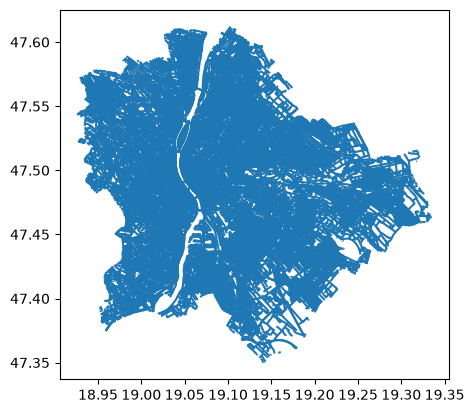

In [4]:
gdf.plot()

In [5]:
colormap = cm.LinearColormap(
    colors=list(reversed(cm.linear.RdYlGn_11.colors)),
    vmin=gdf["_Medianmean"].min(),
    vmax=gdf["_Medianmean"].max()
).to_step(10)


colormap

In [6]:
minx, miny, maxx, maxy = gdf.total_bounds
center = [(miny+maxy)/2, (minx+maxx)/2]

In [ ]:
m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")


folium.GeoJson(
    gdf,
    style_function=lambda feature: {
        "color": colormap(feature["properties"]["_Medianmean"]),
        "weight": 3,            
        "opacity": 0.9
    }
).add_to(m)

colormap.caption = "Traffic accidents (2015–2018)"
colormap.add_to(m)

m.fit_bounds([[miny, minx], [maxy, maxx]])

m.save("budapest_accidents.html")
m